# **FINAL PROJECT (post presentation)**

In [3]:
## helpful packages
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import random
import re
import string

## Install relevant packages if you haven't already
## ! conda activate qss20
## ! conda install nltk spacy vaderSentiment gensim scikit-learn "scipy<1.13"

## nltk imports
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords

## spacy imports
import spacy
### uncomment and run the below line if you haven't loaded the en_core_web_sm library yet
## ! python -m spacy download en_core_web_sm
import en_core_web_sm
nlp = en_core_web_sm.load()

## vectorizer
from sklearn.feature_extraction.text import CountVectorizer

## sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## LDA
from gensim import corpora
import gensim

## repeated printouts and wide-format text
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_colwidth', None)

## **TWEETS**

In [4]:
## The Climate Change Twitter Dataset
## insert link

tweets = pd.read_csv("The Climate Change Twitter Dataset.csv") 

# Preview
tweets.head()
tweets.tail(10)

# Check column info
tweets.info()

# Missing data
tweets.isnull().sum() ## 7309504 missing values 

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness
0,2006-06-06 16:06:42+00:00,6132,NaN,NaN,Weather Extremes,-0.097180,neutral,female,NaN,aggressive
1,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive
2,2006-08-29 01:52:30+00:00,23160,NaN,NaN,Weather Extremes,0.500479,neutral,male,NaN,aggressive
3,2006-11-07 02:46:52+00:00,57868,NaN,NaN,Weather Extremes,0.032816,neutral,male,NaN,aggressive
4,2006-11-27 14:27:43+00:00,304553,NaN,NaN,Importance of Human Intervantion,-0.090428,neutral,male,NaN,aggressive


,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness
11012363,2018-09-02 08:02:48+00:00,1036162510611730432,NaN,NaN,Undefined / One Word Hashtags,-0.112085,believer,male,NaN,not aggressive
11012364,2018-09-02 08:02:52+00:00,1036162527078633473,NaN,NaN,Global stance,0.107227,believer,male,NaN,aggressive
11012365,2018-09-02 08:02:58+00:00,1036162552127008768,NaN,NaN,Importance of Human Intervantion,0.634885,believer,female,NaN,not aggressive
11012366,2018-09-02 08:03:17+00:00,1036162635606241285,13.410530,52.524370,Undefined / One Word Hashtags,-0.393662,believer,female,8.326254,not aggressive
11012367,2018-09-02 08:03:19+00:00,1036162643751567360,-0.243930,51.451650,Weather Extremes,0.514416,believer,male,4.063849,not aggressive
11012368,2018-09-02 08:03:21+00:00,1036162652400173056,NaN,NaN,Weather Extremes,-0.509263,believer,female,NaN,not aggressive
11012369,2018-09-02 08:03:28+00:00,1036162678253932544,NaN,NaN,Global stance,-0.522887,believer,male,NaN,aggressive
11012370,2018-09-02 08:03:37+00:00,1036162717327998976,NaN,NaN,Undefined / One Word Hashtags,-0.060764,believer,male,NaN,not aggressive
11012371,2018-09-02 08:03:48+00:00,1036162762802642944,32.535650,15.593325,Global stance,0.616264,believer,male,-2.634107,not aggressive
11012372,2018-09-02 08:03:49+00:00,1036162767735218176,-82.669508,27.770380,Global stance,0.140839,neutral,female,0.217859,not


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11012373 entries, 0 to 11012372
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 840.2+ MB


created_at               0
id                       0
lng                7309504
lat                7309504
topic                    0
sentiment                0
stance                   0
gender                   0
temperature_avg    7309504
aggressiveness           0
dtype: int64

In [5]:
# make sure lat/lng are numeric
tweets['lat'] = pd.to_numeric(tweets['lat'], errors='coerce')
tweets['lng'] = pd.to_numeric(tweets['lng'], errors='coerce')

# drop rows with missing coords
tweets = tweets.dropna(subset=['lat', 'lng'])

# keep only realistic coords
tweets = tweets[
    (tweets['lat'] >= -90) & (tweets['lat'] <= 90) &
    (tweets['lng'] >= -180) & (tweets['lng'] <= 180)]

In [6]:
import reverse_geocoder as rg

# build list of (lat, lon) tuples
coords = list(zip(tweets['lat'], tweets['lng']))

# reverse_geocoder can take a list directly
results = rg.search(coords)   # returns list of dicts

Loading formatted geocoded file...


In [7]:
countries = [r['cc'] for r in results]
tweets = tweets.reset_index(drop=True)
tweets['country_abbr'] = countries
print(tweets['country_abbr']) ## 3702869, but these are abbreviations not the country's name
tweets.info()

0          US
1          US
2          US
3          US
4          GB
           ..
3702864    TR
3702865    DE
3702866    GB
3702867    SD
3702868    US
Name: country_abbr, Length: 3702869, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
 10  country_abbr     object 
dtypes: float64(4), int64(1), object(6)
memory usage: 310.8+ MB


In [17]:
## change from abbreviations to country names 

## !pip install pycountry
import pycountry

def country_name_from_code(code):
    try:
        return pycountry.countries.get(alpha_2=code).name
    except:
        return None

# after you already created the 'country' column from reverse_geocoder:
tweets['country_name'] = tweets['country_abbr'].apply(country_name_from_code)

tweets[['country_abbr', 'country_name']].head()

tweets.info()

## check that tweets have valid country info

coverage = tweets['country_name'].notna().mean() * 100
print(f"{coverage:.1f}% of tweets have valid country information.") # should be 100%

,country_abbr,country_name
0,US,United States
1,US,United States
2,US,United States
3,US,United States
4,GB,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
 10  country_abbr     object 
 11  country_name     object 
dtypes: float64(4), int64(1), object(7)
memory usage: 339.0+ MB
100.0% of tweets have valid country information.


In [18]:
tweets['country_name'].value_counts().head(20) ## US has the most, only use US tweets?

country_name
United States     2097940
United Kingdom     358601
Canada             289687
Australia          197581
India               86014
Finland             58921
Germany             44284
France              34312
Indonesia           33109
Italy               28417
South Africa        25746
Spain               24215
Ireland             23715
New Zealand         23479
Pakistan            21416
Netherlands         21199
Kenya               20111
Nigeria             20006
Switzerland         19783
Colombia            18926
Name: count, dtype: int64

In [23]:
## created_at -> year & month 

tweets['created_at'].head()

tweets['created_at'] = pd.to_datetime(
    tweets['created_at'], 
    errors='coerce', 
    utc=True  # keep timezone-safe
)

tweets['created_at'] ## there's nothing after 2018 

tweets['year'] = tweets['created_at'].dt.year
tweets['month'] = tweets['created_at'].dt.month
tweets[['year', 'month']] ## july 2006 to september 2018 
tweets.info()

0   2006-07-23 21:52:30+00:00
1   2006-12-14 01:39:10+00:00
2   2006-12-17 19:43:09+00:00
3   2006-12-21 01:39:01+00:00
4   2006-12-31 10:47:25+00:00
Name: created_at, dtype: datetime64[ns, UTC]

0         2006-07-23 21:52:30+00:00
1         2006-12-14 01:39:10+00:00
2         2006-12-17 19:43:09+00:00
3         2006-12-21 01:39:01+00:00
4         2006-12-31 10:47:25+00:00
                     ...           
3702864   2018-09-02 08:02:39+00:00
3702865   2018-09-02 08:03:17+00:00
3702866   2018-09-02 08:03:19+00:00
3702867   2018-09-02 08:03:48+00:00
3702868   2018-09-02 08:03:49+00:00
Name: created_at, Length: 3702869, dtype: datetime64[ns, UTC]

,year,month
0,2006,7
1,2006,12
2,2006,12
3,2006,12
4,2006,12
...,...,...
3702864,2018,9
3702865,2018,9
3702866,2018,9
3702867,2018,9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 14 columns):
 #   Column           Dtype              
---  ------           -----              
 0   created_at       datetime64[ns, UTC]
 1   id               int64              
 2   lng              float64            
 3   lat              float64            
 4   topic            object             
 5   sentiment        float64            
 6   stance           object             
 7   gender           object             
 8   temperature_avg  float64            
 9   aggressiveness   object             
 10  country_abbr     object             
 11  country_name     object             
 12  year             int32              
 13  month            int32              
dtypes: datetime64[ns, UTC](1), float64(4), int32(2), int64(1), object(6)
memory usage: 367.3+ MB


## **DISASTERS**

In [24]:
disasters = pd.read_csv("disasters.csv")  # replace filename
disasters.head() 
disasters.info() ## 4913 rows, 17 columns 

,Disaster Type,Disaster Subtype,Disaster Group,Disaster Subgroup,Event Name,Origin,Country,Location,Latitude,Longitude,start_date,end_date,Total Deaths,No Affected,Reconstruction Costs ('000 US$),Total Damages ('000 US$),CPI
0,Earthquake,Ground movement,Natural,Geophysical,NaN,NaN,Japan,"Nanao, Wajima districts (Isikawa province), Niigata, Toyama provinces",37.336,136.588,2007-03-25,2007-03-25,1.0,NaN,NaN,250000.0,81.101659
1,Storm,Tropical cyclone,Natural,Meteorological,Indhala,NaN,Madagascar,"Diana, Sava, Sofia, Analanjirofo provinces",-14.840,49.940,2007-03-15,2007-03-17,80.0,203182.0,NaN,240000.0,81.101659
2,Flood,Flash flood,Natural,Hydrological,NaN,Storms and heavy rains,Australia,"Gosford, Dungog, Newcastle, Wyong, Port Stephens, Maitland, Cessnock districts (New South Wales province)",-32.870,151.380,2007-06-08,2007-06-12,9.0,5000.0,NaN,1300000.0,81.101659
3,Flood,Riverine flood,Natural,Hydrological,NaN,Heavy rains,Haiti,"Ferrier village (Fort Liberte district, Nord Est province), Ouanaminthe district (Nord Est province), Abricot village (Jeremie district, Grande Anse province)",19.410,-71.780,2007-03-26,2007-03-30,14.0,15000.0,NaN,NaN,81.101659
4,Flood,Riverine flood,Natural,Hydrological,NaN,Heavy rains,Argentina,"Tucuman, Santiago del Estero, Salta, Formosa provinces",NaN,NaN,2007-01-18,2007-03-20,5.0,60000.0,NaN,30000.0,81.101659


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Disaster Type                    4913 non-null   object 
 1   Disaster Subtype                 4212 non-null   object 
 2   Disaster Group                   4913 non-null   object 
 3   Disaster Subgroup                4913 non-null   object 
 4   Event Name                       979 non-null    object 
 5   Origin                           2067 non-null   object 
 6   Country                          4913 non-null   object 
 7   Location                         4787 non-null   object 
 8   Latitude                         1290 non-null   float64
 9   Longitude                        1294 non-null   float64
 10  start_date                       4913 non-null   object 
 11  end_date                         4913 non-null   object 
 12  Total Deaths        

In [26]:
disasters['start_date'] = pd.to_datetime(disasters['start_date'], errors='coerce')
disasters['end_date'] = pd.to_datetime(disasters['end_date'], errors='coerce')

## Extract the year from start_date (main time variable)
disasters['year'] = disasters['start_date'].dt.year
disasters['month'] = disasters['start_date'].dt.month

disasters[['year', 'month']] ## march 2007 to july 2020 
disasters.info()

,year,month
0,2007,3
1,2007,3
2,2007,6
3,2007,3
4,2007,1
...,...,...
4908,2020,4
4909,2020,1
4910,2020,3
4911,2020,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Disaster Type                    4913 non-null   object        
 1   Disaster Subtype                 4212 non-null   object        
 2   Disaster Group                   4913 non-null   object        
 3   Disaster Subgroup                4913 non-null   object        
 4   Event Name                       979 non-null    object        
 5   Origin                           2067 non-null   object        
 6   Country                          4913 non-null   object        
 7   Location                         4787 non-null   object        
 8   Latitude                         1290 non-null   float64       
 9   Longitude                        1294 non-null   float64       
 10  start_date                       4913 non-null   datetime64[

In [32]:
## Clean numeric columns (handle missing values)
disasters['Total Deaths'] = pd.to_numeric(disasters['Total Deaths'], errors='coerce').fillna(0)
disasters['No Affected'] = pd.to_numeric(disasters['No Affected'], errors='coerce').fillna(0)
disasters["Total Damages ('000 US$)"] = pd.to_numeric(
    disasters["Total Damages ('000 US$)"], errors='coerce'
).fillna(0)

## Standardize country names (trim spaces, title case)
disasters['Country'] = disasters['Country'].str.strip()

## realizing a big issue, US has different names in tweets & disasters

disasters['Country'] = disasters['Country'].replace(
    {'United States of America (the)': 'United States'}
)

## Aggregate to country-year level
disaster_agg = (
    disasters
    .groupby(['Country', 'year', 'month'])
    .agg(
        total_deaths=('Total Deaths', 'sum'),
        total_affected=('No Affected', 'sum'),
        total_damages_usd=('Total Damages (\'000 US$)', 'sum'),
        n_events=('Disaster Type', 'count'),
        most_common_type=('Disaster Type', lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    .reset_index()
)

print(disaster_agg)

          Country  year  month  total_deaths  total_affected  \
0     Afghanistan  2007      3         104.0         20000.0   
1     Afghanistan  2007      4          37.0           125.0   
2     Afghanistan  2007      5          33.0          2630.0   
3     Afghanistan  2007      6         113.0          4000.0   
4     Afghanistan  2007      7           9.0             0.0   
...           ...   ...    ...           ...             ...   
3695     Zimbabwe  2015      1          10.0             0.0   
3696     Zimbabwe  2016     12          31.0          2000.0   
3697     Zimbabwe  2017      1         251.0        100000.0   
3698     Zimbabwe  2019      2          26.0       6900000.0   
3699     Zimbabwe  2019      3         628.0        270000.0   

      total_damages_usd  n_events most_common_type  
0                   0.0         1            Flood  
1                   0.0         2            Flood  
2                   0.0         2            Flood  
3                  

In [33]:
disasters['Country'].value_counts().head(20) ## only use US tweets/disasters?

Country
China                         384
United States                 312
Philippines (the)             232
India                         217
Indonesia                     209
Japan                         101
Viet Nam                       99
Mexico                         90
Pakistan                       82
Afghanistan                    79
Brazil                         72
Bangladesh                     68
Colombia                       63
France                         59
Italy                          58
Peru                           55
Australia                      54
Iran (Islamic Republic of)     53
Guatemala                      53
Thailand                       52
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

Text(0.5, 1.0, 'Number of Disasters in the United States Over Time')

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Number of Disasters')

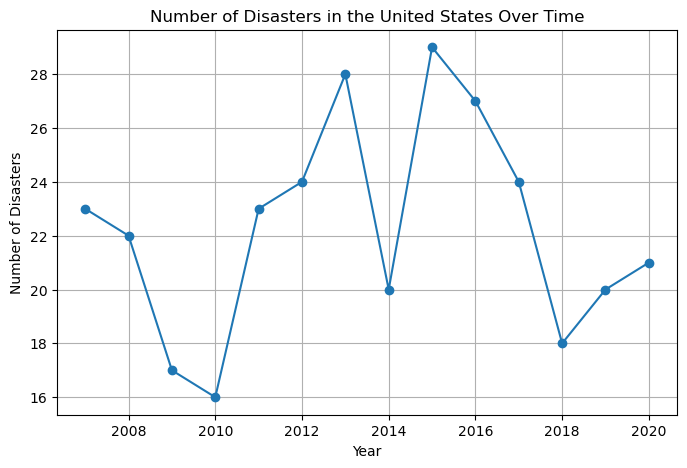

In [36]:
import matplotlib.pyplot as plt

# Filter for US
us_disasters = disaster_agg[disaster_agg['Country'] == 'United States']

# Group by year and count number of disasters
us_yearly = (
    us_disasters.groupby('year')
    .agg(n_events=('n_events', 'sum'))
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(us_yearly['year'], us_yearly['n_events'], marker='o')
plt.title('Number of Disasters in the United States Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Disasters')
plt.grid(True)
plt.show()

<Figure size 900x500 with 0 Axes>

<Axes: xlabel='Country'>

Text(0.5, 1.0, 'Top 10 Countries by Number of Disasters')

Text(0.5, 0, 'Country')

Text(0, 0.5, 'Total Affected Population')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'China'),
  Text(1, 0, 'United States'),
  Text(2, 0, 'Philippines (the)'),
  Text(3, 0, 'India'),
  Text(4, 0, 'Indonesia'),
  Text(5, 0, 'Japan'),
  Text(6, 0, 'Viet Nam'),
  Text(7, 0, 'Mexico'),
  Text(8, 0, 'Pakistan'),
  Text(9, 0, 'Afghanistan')])

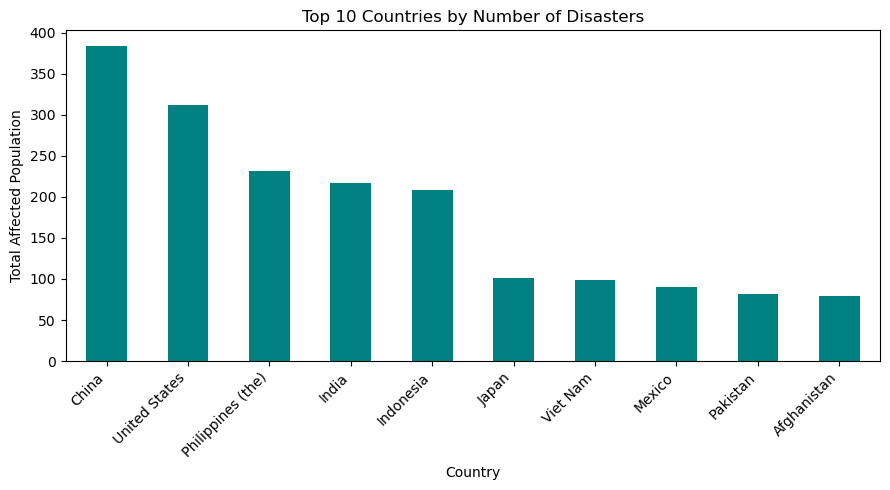

In [38]:
### TOP 10 MOST AFFECTED COUNTRIES ####

top_countries = (
    disaster_agg.groupby('Country')['n_events']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))
top_countries.plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Number of Disasters')
plt.xlabel('Country')
plt.ylabel('Total Affected Population')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **MERGING & PLOTTING (U.S. only)** 

In [68]:
tweets_disasters = tweets.merge(
    disaster_agg,
    left_on=['country_name', 'year', 'month'],
    right_on=['Country', 'year', 'month'],
    how='left'
)

In [69]:
tweets_disasters.info()
tweets_disasters[['country_name','year','month','n_events']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 20 columns):
 #   Column             Dtype              
---  ------             -----              
 0   created_at         datetime64[ns, UTC]
 1   id                 int64              
 2   lng                float64            
 3   lat                float64            
 4   topic              object             
 5   sentiment          float64            
 6   stance             object             
 7   gender             object             
 8   temperature_avg    float64            
 9   aggressiveness     object             
 10  country_abbr       object             
 11  country_name       object             
 12  year               int32              
 13  month              int32              
 14  Country            object             
 15  total_deaths       float64            
 16  total_affected     float64            
 17  total_damages_usd  float64            
 18  n_

,country_name,year,month,n_events
0,United States,2006,7,NaN
1,United States,2006,12,NaN
2,United States,2006,12,NaN
3,United States,2006,12,NaN
4,United Kingdom,2006,12,NaN


In [70]:
tweets_disasters = tweets.merge(
    disaster_agg,
    left_on=['country_name', 'year', 'month'],
    right_on=['Country', 'year', 'month'],
    how='left',
    validate='m:1'   # many tweets to 1 disaster row
)

tweets.shape, tweets_disasters.shape
tweets_disasters.info()
tweets_disasters.isnull().sum() ## 7309504 missing values 
tweets_disasters.head(100)

((3702869, 14), (3702869, 20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 20 columns):
 #   Column             Dtype              
---  ------             -----              
 0   created_at         datetime64[ns, UTC]
 1   id                 int64              
 2   lng                float64            
 3   lat                float64            
 4   topic              object             
 5   sentiment          float64            
 6   stance             object             
 7   gender             object             
 8   temperature_avg    float64            
 9   aggressiveness     object             
 10  country_abbr       object             
 11  country_name       object             
 12  year               int32              
 13  month              int32              
 14  Country            object             
 15  total_deaths       float64            
 16  total_affected     float64            
 17  total_damages_usd  float64            
 18  n_

created_at                 0
id                         0
lng                        0
lat                        0
topic                      0
sentiment                  0
stance                     0
gender                     0
temperature_avg            0
aggressiveness             0
country_abbr               0
country_name              42
year                       0
month                      0
Country              1633880
total_deaths         1633880
total_affected       1633880
total_damages_usd    1633880
n_events             1633880
most_common_type     1633880
dtype: int64

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness,country_abbr,country_name,year,month,Country,total_deaths,total_affected,total_damages_usd,n_events,most_common_type
0,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,US,United States,2006,7,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-12-14 01:39:10+00:00,1092823,-122.419420,37.774930,Ideological Positions on Global Warming,-0.544195,neutral,male,4.228540,aggressive,US,United States,2006,12,NaN,NaN,NaN,NaN,NaN,NaN
2,2006-12-17 19:43:09+00:00,1278023,-79.791980,36.072640,Weather Extremes,-0.565028,denier,male,5.478175,aggressive,US,United States,2006,12,NaN,NaN,NaN,NaN,NaN,NaN
3,2006-12-21 01:39:01+00:00,1455543,-121.805790,38.004920,Weather Extremes,0.650960,neutral,male,-1.652156,not aggressive,US,United States,2006,12,NaN,NaN,NaN,NaN,NaN,NaN
4,2006-12-31 10:47:25+00:00,1893063,-1.902691,52.479699,Weather Extremes,0.670905,neutral,male,4.864521,aggressive,GB,United Kingdom,2006,12,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2007-03-17 16:21:25+00:00,8960981,6.632702,46.521827,Weather Extremes,0.014822,neutral,male,1.953192,aggressive,CH,Switzerland,2007,3,NaN,NaN,NaN,NaN,NaN,NaN
96,2007-03-19 05:16:29+00:00,9542461,-122.330062,47.603832,Weather Extremes,0.166310,neutral,male,2.199456,aggressive,US,United States,2007,3,United States,20.0,0.0,600000.0,1.0,Storm
97,2007-03-19 17:21:37+00:00,9732201,-0.125740,51.508530,Seriousness of Gas Emissions,-0.614265,neutral,male,-2.360052,aggressive,GB,United Kingdom,2007,3,NaN,NaN,NaN,NaN,NaN,NaN
98,2007-03-20 00:30:56+00:00,9840761,-0.125740,51.508530,Global stance,-0.492482,believer,male,-3.066156,not aggressive,GB,United Kingdom,2007,3,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
cols_to_drop = [
    'created_at',
    'lng',
    'lat',
    'gender', 
    'Country'
]

tweets_disasters = tweets_disasters.drop(columns=cols_to_drop)
tweets_disasters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 15 columns):
 #   Column             Dtype  
---  ------             -----  
 0   id                 int64  
 1   topic              object 
 2   sentiment          float64
 3   stance             object 
 4   temperature_avg    float64
 5   aggressiveness     object 
 6   country_abbr       object 
 7   country_name       object 
 8   year               int32  
 9   month              int32  
 10  total_deaths       float64
 11  total_affected     float64
 12  total_damages_usd  float64
 13  n_events           float64
 14  most_common_type   object 
dtypes: float64(6), int32(2), int64(1), object(6)
memory usage: 395.5+ MB


In [72]:
## make NA = 0 because it means that there were no disasters happening in the year/month of that tweet

disaster_cols = ['total_deaths', 'total_affected', 'total_damages_usd', 'n_events']

tweets_disasters[disaster_cols] = (
    tweets_disasters[disaster_cols].fillna(0)
)

In [73]:
tweets_disasters.head()
tweets_disasters[disaster_cols].isna().sum()

,id,topic,sentiment,stance,temperature_avg,aggressiveness,country_abbr,country_name,year,month,total_deaths,total_affected,total_damages_usd,n_events,most_common_type
0,13275,Weather Extremes,0.575777,neutral,-1.114768,aggressive,US,United States,2006,7,0.0,0.0,0.0,0.0,NaN
1,1092823,Ideological Positions on Global Warming,-0.544195,neutral,4.228540,aggressive,US,United States,2006,12,0.0,0.0,0.0,0.0,NaN
2,1278023,Weather Extremes,-0.565028,denier,5.478175,aggressive,US,United States,2006,12,0.0,0.0,0.0,0.0,NaN
3,1455543,Weather Extremes,0.650960,neutral,-1.652156,not aggressive,US,United States,2006,12,0.0,0.0,0.0,0.0,NaN
4,1893063,Weather Extremes,0.670905,neutral,4.864521,aggressive,GB,United Kingdom,2006,12,0.0,0.0,0.0,0.0,NaN


total_deaths         0
total_affected       0
total_damages_usd    0
n_events             0
dtype: int64

In [75]:
tweets_us = tweets_disasters[tweets_disasters['country_name'] == 'United States']

tweets_us.head(20)
tweets_us['country_name'].unique()
tweets_us.shape

,id,topic,sentiment,stance,temperature_avg,aggressiveness,country_abbr,country_name,year,month,total_deaths,total_affected,total_damages_usd,n_events,most_common_type
0,13275,Weather Extremes,0.575777,neutral,-1.114768,aggressive,US,United States,2006,7,0.0,0.0,0.0,0.0,NaN
1,1092823,Ideological Positions on Global Warming,-0.544195,neutral,4.228540,aggressive,US,United States,2006,12,0.0,0.0,0.0,0.0,NaN
2,1278023,Weather Extremes,-0.565028,denier,5.478175,aggressive,US,United States,2006,12,0.0,0.0,0.0,0.0,NaN
3,1455543,Weather Extremes,0.650960,neutral,-1.652156,not aggressive,US,United States,2006,12,0.0,0.0,0.0,0.0,NaN
5,2266613,Weather Extremes,-0.567821,neutral,15.600876,aggressive,US,United States,2007,1,89.0,0.0,500000.0,2.0,Flood
11,3040243,Weather Extremes,0.027765,neutral,-9.293259,aggressive,US,United States,2007,1,89.0,0.0,500000.0,2.0,Flood
12,3081573,Weather Extremes,0.026214,neutral,-2.851010,not aggressive,US,United States,2007,1,89.0,0.0,500000.0,2.0,Flood
13,3241963,Weather Extremes,-0.377974,denier,-3.005815,aggressive,US,United States,2007,1,89.0,0.0,500000.0,2.0,Flood
18,3922373,Weather Extremes,0.567071,denier,3.746511,not aggressive,US,United States,2007,1,89.0,0.0,500000.0,2.0,Flood
26,5144253,Weather Extremes,0.159730,neutral,1.846384,not aggressive,US,United States,2007,2,40.0,6600.0,570000.0,3.0,Storm


array(['United States'], dtype=object)

(2097940, 15)

In [76]:
import statsmodels.api as sm

X = tweets_us[['n_events', 'total_deaths', 'total_affected', 'total_damages_usd']]
X = sm.add_constant(X)
y = tweets_us['sentiment']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     430.6
Date:                Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:49:09   Log-Likelihood:            -1.2283e+06
No. Observations:             2097940   AIC:                         2.457e+06
Df Residuals:                 2097935   BIC:                         2.457e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0017      0.00

In [80]:
tweets_us[['sentiment', 'n_events', 'total_deaths', 
           'total_affected', 'total_damages_usd']].corr()

,sentiment,n_events,total_deaths,total_affected,total_damages_usd
sentiment,1.000000,-0.021060,-0.016973,0.015277,-0.014736
n_events,-0.021060,1.000000,0.548945,0.018915,0.180238
total_deaths,-0.016973,0.548945,1.000000,0.120997,0.441998
total_affected,0.015277,0.018915,0.120997,1.000000,-0.037231
total_damages_usd,-0.014736,0.180238,0.441998,-0.037231,1.000000


In [81]:
## STANCE ##
## doesn't work because it's a string not a number
'''
tweets_us[['stance', 'n_events', 'total_deaths', 
           'total_affected', 'total_damages_usd']].corr()
'''

ValueError: could not convert string to float: 'neutral'

In [83]:
import seaborn as sns

corrs = country_merge[['mean_sentiment', 'total_damages_usd', 'total_deaths', 'total_affected', 'n_events']].corr()
print(corrs['mean_sentiment'])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics = ['total_damages_usd', 'total_deaths', 'total_affected', 'n_events']

for i, m in enumerate(metrics):
    sns.regplot(data=country_merge, x=m, y='mean_sentiment', ax=axes[i],
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    axes[i].set_xscale('log')
    axes[i].set_title(f'Mean Sentiment vs. {m.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

,country_name,mean_sentiment,total_damages_usd,total_deaths,total_affected,n_events
0,Afghanistan,0.106449,6000.0,2145.0,67600120.0,78.0
1,Albania,0.098143,151300.0,18.0,487300.0,32.0
2,Algeria,0.246037,0.0,78.0,162600.0,15.0
3,American Samoa,-0.031548,0.0,0.0,0.0,0.0
4,Andorra,0.226739,0.0,0.0,0.0,0.0


In [85]:
corrs = tweets_us[['sentiment',
                   'n_events',
                   'total_deaths',
                   'total_affected',
                   'total_damages_usd']].corr()

print(corrs['sentiment'])

import seaborn as sns
import matplotlib.pyplot as plt

# optional: sample for a manageable plot
sample_size = 100_000
if len(tweets_us) > sample_size:
    df_plot = tweets_us.sample(sample_size, random_state=0)
else:
    df_plot = tweets_us.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics = ['n_events', 'total_deaths', 'total_affected', 'total_damages_usd']

for i, m in enumerate(metrics):
    sns.regplot(
        data=df_plot,
        x=m,
        y='sentiment',
        ax=axes[i],
        scatter_kws={'alpha': 0.15, 's': 10},      # light points
        line_kws={'color': 'red'}
    )
    
    axes[i].set_xscale('log')                     # disaster metrics are skewed
    axes[i].set_xlabel(m.replace('_', ' ').title())
    axes[i].set_ylabel("Sentiment")
    axes[i].set_title(f"Sentiment vs {m.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

sentiment            1.000000
n_events            -0.021060
total_deaths        -0.016973
total_affected       0.015277
total_damages_usd   -0.014736
Name: sentiment, dtype: float64


'\n# optional: sample for a manageable plot\nsample_size = 100_000\nif len(tweets_us) > sample_size:\n    df_plot = tweets_us.sample(sample_size, random_state=0)\nelse:\n    df_plot = tweets_us.copy()\n\nfig, axes = plt.subplots(2, 2, figsize=(12, 10))\naxes = axes.flatten()\n'

<Axes: title={'center': 'Sentiment vs N Events'}, xlabel='n_events', ylabel='sentiment'>

Text(0.5, 516.5, 'N Events')

Text(24.0, 0.5, 'Sentiment')

...

<Axes: title={'center': 'Sentiment vs Total Damages Usd'}, xlabel='total_damages_usd', ylabel='sentiment'>

Text(0.5, 24.0, 'Total Damages Usd')

Text(617.5600910025634, 0.5, 'Sentiment')

Text(0.5, 1.0, 'Sentiment vs Total Damages Usd')

<Figure size 640x480 with 0 Axes>

(707693, 15)

sentiment            1.000000
n_events            -0.026829
total_deaths        -0.044195
total_affected       0.000589
total_damages_usd   -0.013798
Name: sentiment, dtype: float64


<Axes: xlabel='n_events', ylabel='sentiment'>

Text(0.5, 0, 'N Events')

Text(0, 0.5, 'Sentiment')

...

Text(0.5, 1.0, 'Sentiment vs Total Affected (2018–2022)')

<Axes: xlabel='total_damages_usd', ylabel='sentiment'>

Text(0.5, 0, 'Total Damages Usd')

Text(0, 0.5, 'Sentiment')

Text(0.5, 1.0, 'Sentiment vs Total Damages Usd (2018–2022)')

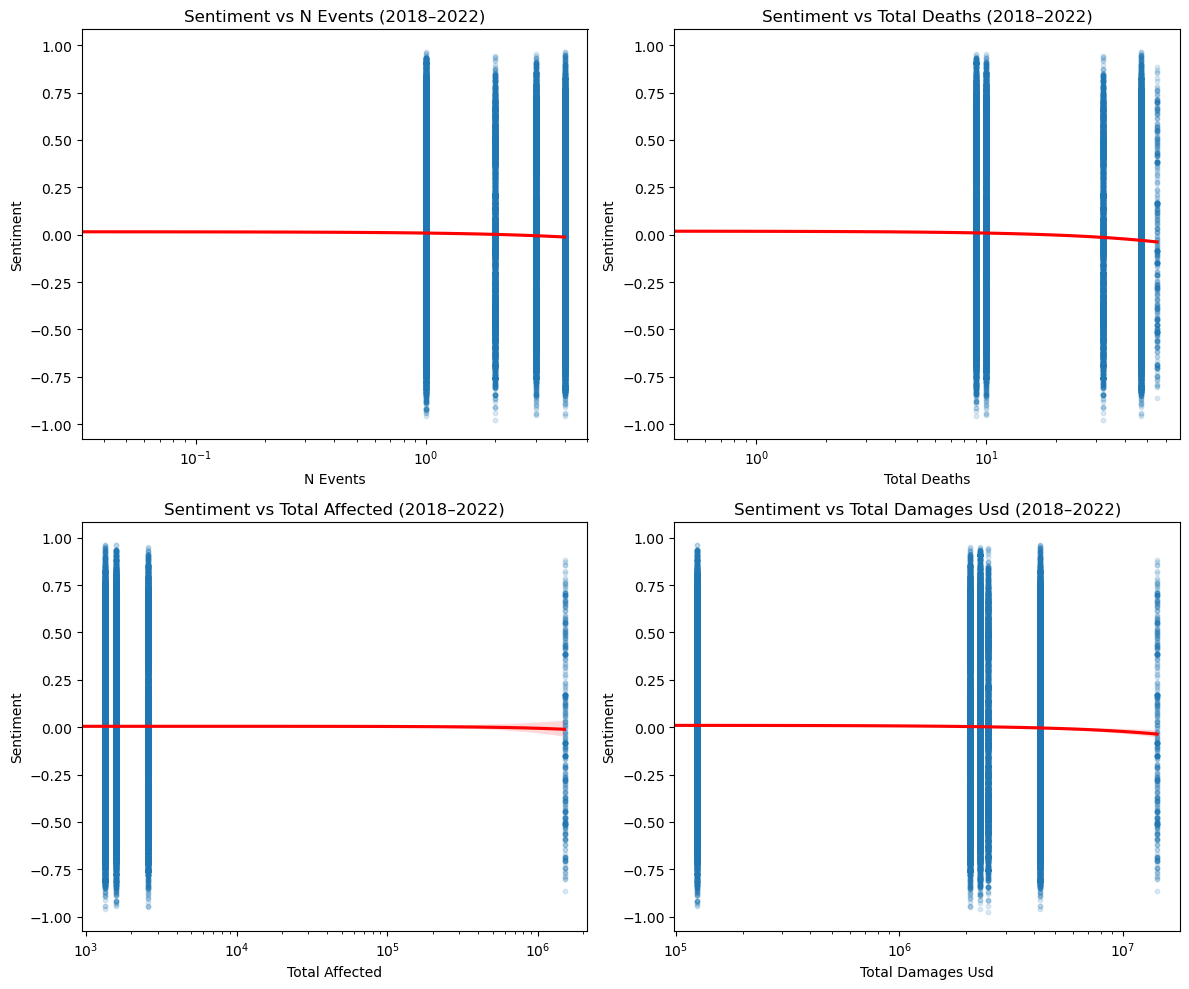

In [87]:
tweets_us_18_22 = tweets_us[(tweets_us['year'] >= 2018) & (tweets_us['year'] <= 2022)]
tweets_us_18_22.shape

corrs_18_22 = tweets_us_18_22[['sentiment',
                               'n_events',
                               'total_deaths',
                               'total_affected',
                               'total_damages_usd']].corr()

print(corrs_18_22['sentiment'])

sample_size = 100_000
if len(tweets_us_18_22) > sample_size:
    df_plot = tweets_us_18_22.sample(sample_size, random_state=0)
else:
    df_plot = tweets_us_18_22.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics = ['n_events', 'total_deaths', 'total_affected', 'total_damages_usd']

for i, m in enumerate(metrics):
    sns.regplot(
        data=df_plot,
        x=m,
        y='sentiment',
        ax=axes[i],
        scatter_kws={'alpha': 0.15, 's': 10},
        line_kws={'color': 'red'}
    )
    
    axes[i].set_xscale('log')
    axes[i].set_xlabel(m.replace('_', ' ').title())
    axes[i].set_ylabel("Sentiment")
    axes[i].set_title(f"Sentiment vs {m.replace('_', ' ').title()} (2018–2022)")

plt.tight_layout()
plt.show()